In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/mrajareivan/feature-engineering/__results__.html
/kaggle/input/notebooks/mrajareivan/feature-engineering/__notebook__.ipynb
/kaggle/input/notebooks/mrajareivan/feature-engineering/AML_data_feature_engineering_with_cat_feature.parquet
/kaggle/input/notebooks/mrajareivan/feature-engineering/__output__.json
/kaggle/input/notebooks/mrajareivan/feature-engineering/custom.css


In [2]:
df = pd.read_parquet("/kaggle/input/notebooks/mrajareivan/feature-engineering/AML_data_feature_engineering_with_cat_feature.parquet")
df.head()

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,...,receiver_avg_amount_1h,receiver_avg_amount_24h,sender_amount_vs_1h_avg,sender_amount_vs_24h_avg,receiver_amount_vs_1h_avg,receiver_amount_vs_24h_avg,sender_is_new_account,receiver_is_new_account,pair_tx_count_history,is_repeated_pair
0,1900-01-01 10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,...,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0,0
1,1900-01-01 10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,...,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0,0
2,1900-01-01 10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,...,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0,0
3,1900-01-01 10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,...,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0,0
4,1900-01-01 10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,...,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0,0


In [3]:
df.shape

(9504852, 64)

In [4]:
df.columns

Index(['Time', 'Date', 'Sender_account', 'Receiver_account', 'Amount',
       'Payment_currency', 'Received_currency', 'Sender_bank_location',
       'Receiver_bank_location', 'Payment_type', 'Is_laundering',
       'Laundering_type', 'Datetime', 'is_cross_border',
       'is_currency_conversion', 'hour', 'day_of_week', 'date_only',
       'day_of_month', 'minute', 'month', 'is_weekend', 'hour_sin', 'hour_cos',
       'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'log_amount',
       'account_pair', 'sender_tx_count_history',
       'sender_total_amount_history', 'sender_avg_amount_history',
       'sender_amount_vs_history_ratio', 'sender_new_receiver',
       'sender_unique_receivers_history', 'receiver_tx_count_history',
       'receiver_total_amount_history', 'receiver_avg_amount_history',
       'receiver_amount_vs_history_ratio', 'receiver_new_sender',
       'receiver_unique_senders_history', 'sender_time_since_last_tx',
       'receiver_time_since_last_tx', 'sender_tx_count_1

In [5]:
df['Datetime'].is_monotonic_increasing

True

In [6]:
n = len(df)

train_end = int(n * 0.85)

dev_df = df.iloc[:train_end].copy()
test_df = df.iloc[train_end:].copy()

print("Train and Val  :", dev_df.shape)
print("Test :", test_df.shape)

Train and Val  : (8079124, 64)
Test : (1425728, 64)


In [7]:
print(
    "Train and Val:",
    dev_df["Datetime"].min(),
    "→",
    dev_df["Datetime"].max()
)


print(
    "Test:",
    test_df["Datetime"].min(),
    "→",
    test_df["Datetime"].max()
)

Train and Val: 2022-10-07 10:35:19 → 2023-07-05 15:24:39
Test: 2023-07-05 15:24:42 → 2023-08-23 10:57:12


In [8]:
numeric_features = [
    # Transaction
    "Amount",
    "log_amount",

    # Temporal
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",

    # Sender history
    "sender_tx_count_history",
    "sender_total_amount_history",
    "sender_avg_amount_history",
    "sender_amount_vs_history_ratio",
    "sender_unique_receivers_history",
    "sender_time_since_last_tx",
    "sender_tx_count_1h",
    "sender_total_amount_1h",
    "sender_avg_amount_1h",
    "sender_tx_count_24h",
    "sender_total_amount_24h",
    "sender_avg_amount_24h",
    "sender_amount_vs_1h_avg",
    "sender_amount_vs_24h_avg",

    # Receiver history
    "receiver_tx_count_history",
    "receiver_total_amount_history",
    "receiver_avg_amount_history",
    "receiver_amount_vs_history_ratio",
    "receiver_unique_senders_history",
    "receiver_time_since_last_tx",
    "receiver_tx_count_1h",
    "receiver_total_amount_1h",
    "receiver_avg_amount_1h",
    "receiver_tx_count_24h",
    "receiver_total_amount_24h",
    "receiver_avg_amount_24h",
    "receiver_amount_vs_1h_avg",
    "receiver_amount_vs_24h_avg",

    # Pair behavior
    "pair_tx_count_history",

    # New account indicators
    # "sender_is_new_account",
    # "receiver_is_new_account"
]

categorical_features = [
    # Transaction characteristics
    "is_cross_border",
    "is_currency_conversion",
    
    "Payment_currency",
    "Received_currency",
    "Sender_bank_location",
    "Receiver_bank_location",
    "Payment_type"]

feature_cols = numeric_features + categorical_features

target_col = "Is_laundering"

X_dev= dev_df[feature_cols].copy()
y_dev = dev_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

In [9]:
def target_summary(y, name):
    count = y.value_counts().sort_index()
    pct = y.value_counts(normalize=True).sort_index() * 100

    result = pd.DataFrame({
        "count": count,
        "percentage": pct
    })

    print(f"\n{name}")
    display(result)

    
target_summary(y_dev, "TRAIN and VALIDATION")
target_summary(y_test, "TEST")


TRAIN and VALIDATION


,count,percentage
Is_laundering,,
0,8070948,99.898801
1,8176,0.101199



TEST


,count,percentage
Is_laundering,,
0,1424031,99.880973
1,1697,0.119027


In [10]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline


# =========================================================
# 1. TIME SERIES CV
# =========================================================

tscv = TimeSeriesSplit(
    n_splits=5
)


# =========================================================
# 2. PREPROCESSOR
# =========================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True,
                dtype=np.float64
            ),
            categorical_features
        )
    ],
    remainder="drop",

    # Mempertahankan output sparse ketika memungkinkan
    sparse_threshold=1.0
)




In [11]:
# =========================================================
# 3. RANDOM UNDERSAMPLING
# =========================================================

rus = RandomUnderSampler(
    sampling_strategy=0.10,
    random_state=42
)
X_downsampled, y_downsampled = rus.fit_resample(X_dev, y_dev)


class_dist_downsampled = y_downsampled.value_counts()
class_dist = y_dev.value_counts()

print("Sebelum downsampling :", X_dev.shape)
print("Sesudah downsampling :", X_downsampled.shape)

print("\nDistribusi target sebelum downsampling:")
print(y_dev.value_counts())

print("\nDistribusi target sesudah downsampling:")
print(y_downsampled.value_counts())


Sebelum downsampling : (8079124, 42)
Sesudah downsampling : (89936, 42)

Distribusi target sebelum downsampling:
Is_laundering
0    8070948
1       8176
Name: count, dtype: int64

Distribusi target sesudah downsampling:
Is_laundering
0    81760
1     8176
Name: count, dtype: int64


## Logistic Regression Model

In [12]:
print("===============LOGISTIC REGRESSION PART===============")

===============LOGISTIC REGRESSION PART===============


In [13]:
logreg_pipeline = ImbPipeline([
    
    # IMPORTANT:
    # Sampling dilakukan hanya pada training fold
    ("sampler", rus),

    # Setelah jumlah row dikurangi,
    # baru lakukan preprocessing
    ("preprocessor", preprocessor),


    ("model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )
    )
])


In [14]:
import gc

# Downcast numerik ke float32
X_dev[numeric_features] = X_dev[numeric_features].astype('float32')
X_test[numeric_features] = X_test[numeric_features].astype('float32')

# Hapus variabel besar yang tidak dipakai lagi
del df, dev_df, test_df, X_downsampled, y_downsampled
gc.collect()

0

In [15]:
thresholds = np.arange(0.05, 1.00, 0.05)
all_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_dev), 1):

    # Fit & Predict langsung tanpa menyimpan variabel intermediate X_train/y_train
    logreg_pipeline.fit(X_dev.iloc[train_idx], y_dev.iloc[train_idx])
    y_prob = logreg_pipeline.predict_proba(X_dev.iloc[val_idx])[:, 1]
    y_val = y_dev.iloc[val_idx].to_numpy().astype(bool)

    # Matriks perbandingan (n_samples, n_thresholds)
    preds = y_prob[:, None] >= thresholds[None, :]

    # Hitung TP, FP, FN sekaligus untuk seluruh threshold
    tp = np.sum(preds & y_val[:, None], axis=0)
    fp = np.sum(preds & ~y_val[:, None], axis=0)
    fn = np.sum(~preds & y_val[:, None], axis=0)

    # Vektorikasi perhitungan metrik (bebas pembagian dengan nol)
    precision = np.where((tp + fp) > 0, tp / (tp + fp), 0.0)
    recall = np.where((tp + fn) > 0, tp / (tp + fn), 0.0)
    f1 = np.where((precision + recall) > 0, 2 * precision * recall / (precision + recall), 0.0)

    # Simpan hasil per fold
    fold_df = pd.DataFrame({
        "fold": fold,
        "threshold": thresholds,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })
    
    all_results.append(fold_df)

threshold_results = pd.concat(all_results, ignore_index=True)


##

In [16]:
threshold_summary_lr = (
    threshold_results
    .groupby("threshold")
    [["precision", "recall", "f1"]]
    .mean()
    .reset_index()
)

display(threshold_summary_lr)

,threshold,precision,recall,f1
0,0.05,0.003103,0.990189,0.006187
1,0.10,0.004079,0.983429,0.008124
2,0.15,0.004910,0.974098,0.009771
3,0.20,0.005673,0.966028,0.011279
4,0.25,0.006355,0.951918,0.012624
5,0.30,0.007015,0.939095,0.013924
6,0.35,0.007661,0.925583,0.015194
7,0.40,0.008307,0.910485,0.016463
8,0.45,0.008969,0.894381,0.017757
9,0.50,0.009632,0.874992,0.019051


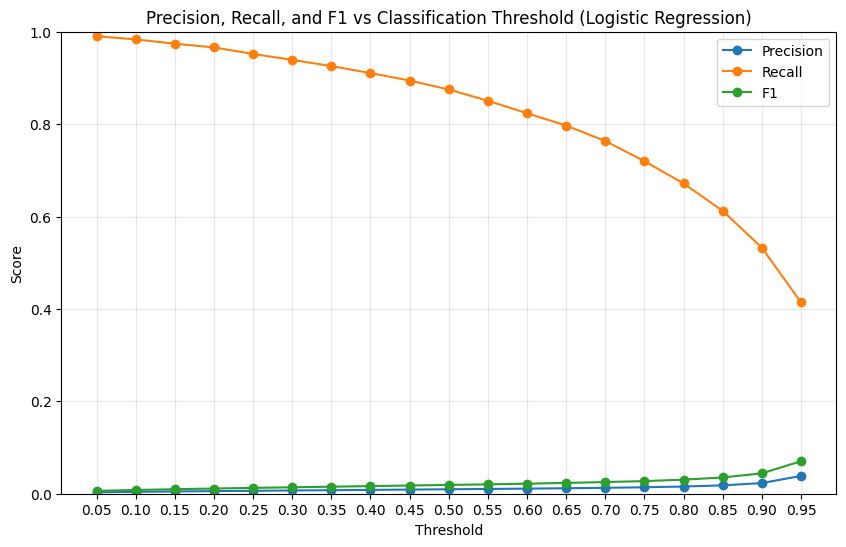

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_summary_lr["threshold"],
    threshold_summary_lr["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_summary_lr["threshold"],
    threshold_summary_lr["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_summary_lr["threshold"],
    threshold_summary_lr["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 vs Classification Threshold (Logistic Regression)")

plt.xticks(threshold_summary_lr["threshold"])
plt.ylim(0, 1)

plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig("threshold_evaluation_lr.png", dpi=300, bbox_inches="tight")

plt.show()

## XGboost Classifier Model

In [18]:
del all_results
gc.collect()

4757

In [19]:
print("===============XGBOOST PART===============")

# =========================================================
# 2. Imports
# =========================================================

import numpy as np
import optuna

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import average_precision_score


# =========================================================
# 3. Class imbalance
# =========================================================

original_ratio = class_dist[0] / class_dist[1] ## --> for scale_pos_weight


# =========================================================
# 4. XGBoost Pipeline
# =========================================================

xgb_pipeline = ImbPipeline([
    # IMPORTANT:
    # Sampling dilakukan hanya pada training fold
    # ("sampler", rus),
    ("preprocessor", preprocessor),

    (
        "model",
        XGBClassifier(
            objective="binary:logistic",

            # Faster CPU training
            tree_method="hist",

            # We optimize PR-AUC
            eval_metric="aucpr",

            random_state=42,
            n_jobs=-1
        )
    )
])



# =========================================================
# 6. Optuna Objective Function
# =========================================================

def objective(trial):

    # -----------------------------------------------------
    # Hyperparameters
    # -----------------------------------------------------

    params = {
        "model__max_depth": trial.suggest_int(
            "max_depth",
            3,
            7
        ),

        "model__learning_rate": trial.suggest_float(
            "learning_rate",
            0.03,
            0.10,
            log=True
        ),

        "model__n_estimators": trial.suggest_int(
            "n_estimators",
            300,
            500
        ),

        "model__min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            5
        ),

        "model__subsample": trial.suggest_float(
            "subsample",
            0.8,
            1.0
        ),

        "model__colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.8,
            1.0
        ),
        
        "model__scale_pos_weight": trial.suggest_float(
        "scale_pos_weight",
        1.0,
        original_ratio,
        log=True
    )
    }


    # -----------------------------------------------------
    # Store score of every fold
    # -----------------------------------------------------

    fold_scores = []


    # -----------------------------------------------------
    # 5-Fold Time Series CV
    # -----------------------------------------------------

    for fold, (train_idx, val_idx) in enumerate(
        tscv.split(X_dev),
        start=1
    ):

        # -------------------------------------------------
        # Train / validation split
        # -------------------------------------------------

        X_train = X_dev.iloc[train_idx]
        X_val = X_dev.iloc[val_idx]

        y_train = y_dev.iloc[train_idx]
        y_val = y_dev.iloc[val_idx]


        # -------------------------------------------------
        # Set hyperparameters
        # -------------------------------------------------

        model = xgb_pipeline.set_params(**params)


        # -------------------------------------------------
        # Train
        # -------------------------------------------------

        model.fit(
            X_train,
            y_train
        )


        # -------------------------------------------------
        # Validation probability
        # -------------------------------------------------

        y_prob = model.predict_proba(
            X_val
        )[:, 1]


        # -------------------------------------------------
        # PR-AUC
        # -------------------------------------------------

        score = average_precision_score(
            y_val,
            y_prob
        )

        fold_scores.append(score)


        # -------------------------------------------------
        # Report intermediate score to Optuna
        # -------------------------------------------------

        mean_score_so_far = np.mean(fold_scores)

        trial.report(
            mean_score_so_far,
            step=fold
        )


        # -------------------------------------------------
        # Pruning
        # -------------------------------------------------

        if trial.should_prune():
            raise optuna.TrialPruned()


    # -----------------------------------------------------
    # Return mean CV PR-AUC
    # -----------------------------------------------------

    return np.mean(fold_scores)


# =========================================================
# 7. Create Optuna Study
# =========================================================

study = optuna.create_study(
    direction="maximize",

    sampler=optuna.samplers.TPESampler(
        seed=42
    ),

    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=1
    )
)


# =========================================================
# 8. Run Hyperparameter Optimization
# =========================================================

study.optimize(
    objective,
    n_trials=30,
    n_jobs=1,
    show_progress_bar=True
)


# =========================================================
# 9. Best Result
# =========================================================

print("Best PR-AUC:")
print(study.best_value)

print("\nBest Hyperparameters:")

for param, value in study.best_params.items():
    print(f"{param}: {value}")

===============XGBOOST PART===============


[I 2026-09-20 10:44:33,241] A new study created in memory with name: no-name-2e1d38ab-f82b-4c88-bec5-4c898004e222


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-09-20 10:57:13,387] Trial 0 finished with value: 0.9276523982326669 and parameters: {'max_depth': 4, 'learning_rate': 0.09423875899553878, 'n_estimators': 447, 'min_child_weight': 3, 'subsample': 0.8312037280884873, 'colsample_bytree': 0.8311989040672406, 'scale_pos_weight': 1.4925353279336913}. Best is trial 0 with value: 0.9276523982326669.
[I 2026-09-20 11:12:06,411] Trial 1 finished with value: 0.9246312347712877 and parameters: {'max_depth': 7, 'learning_rate': 0.06186307704341194, 'n_estimators': 442, 'min_child_weight': 1, 'subsample': 0.9939819704323989, 'colsample_bytree': 0.9664885281600843, 'scale_pos_weight': 4.323393494794561}. Best is trial 0 with value: 0.9276523982326669.
[I 2026-09-20 11:21:50,446] Trial 2 finished with value: 0.9028062339057634 and parameters: {'max_depth': 3, 'learning_rate': 0.03741274507279066, 'n_estimators': 361, 'min_child_weight': 3, 'subsample': 0.8863890037284232, 'colsample_bytree': 0.8582458280396084, 'scale_pos_weight': 67.93949497

In [20]:
from sklearn.base import clone  # Import clone

# 1. Ambil best hyperparameters dari Optuna
# =========================================================

best_params = study.best_params

print("Best Optuna Hyperparameters:")
for param, value in best_params.items():
    print(f"{param}: {value}")


# =========================================================
# 2. Ubah parameter Optuna menjadi parameter Pipeline
# =========================================================

best_params_pipeline = {
    f"model__{param}": value
    for param, value in best_params.items()
}


# =========================================================
# 3. Buat pipeline dengan best hyperparameters
# =========================================================

best_xgb_pipeline = clone(xgb_pipeline).set_params(
    **best_params_pipeline
)


thresholds = np.arange(0.05, 1.00, 0.05)
all_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_dev), 1):
    # 2. Duplicate best estimator agar hyperparameter terbaiknya dipakai,
    # tetapi bobot model di-reset untuk fold ini
    fold_pipeline = clone(best_xgb_pipeline)
    
    # 3. Fit & Predict menggunakan fold_pipeline
    fold_pipeline.fit(X_dev.iloc[train_idx], y_dev.iloc[train_idx])
    y_prob = fold_pipeline.predict_proba(X_dev.iloc[val_idx])[:, 1]
    y_val = y_dev.iloc[val_idx].to_numpy().astype(bool)

    # itung PR-AUC untuk fold ini
    fold_pr_auc = average_precision_score(y_val, y_prob)

    ## vectorized calculation utk menghitung pre, re, f1 di tiap threshold, pake loop lama
    preds = y_prob[:, None] >= thresholds[None, :]

    tp = np.sum(preds & y_val[:, None], axis=0)
    fp = np.sum(preds & ~y_val[:, None], axis=0)
    fn = np.sum(~preds & y_val[:, None], axis=0)


    precision = np.where((tp + fp) > 0, tp / (tp + fp), 0.0)
    recall = np.where((tp + fn) > 0, tp / (tp + fn), 0.0)
    f1 = np.where((precision + recall) > 0, 2 * precision * recall / (precision + recall), 0.0)

    fold_df = pd.DataFrame({
        "fold": fold,
        "threshold": thresholds,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "pr_auc": fold_pr_auc
    })
    
    all_results.append(fold_df)

threshold_results = pd.concat(all_results, ignore_index=True)

# 4. Cari threshold terbaik berdasarkan rata-rata F1-score lintas fold
mean_scores = threshold_results.groupby("threshold")[["precision", "recall", "f1", "pr_auc"]].mean().reset_index()
best_threshold = mean_scores.loc[mean_scores["f1"].idxmax(), "threshold"]

print(f"Threshold Optimal: {best_threshold:.2f}")

Best Optuna Hyperparameters:
max_depth: 4
learning_rate: 0.09755088584498559
n_estimators: 488
min_child_weight: 3
subsample: 0.8226476225148368
colsample_bytree: 0.885805580270012
scale_pos_weight: 2.1352744882077106
Threshold Optimal: 0.75


In [21]:
threshold_summary_xgb = (
    threshold_results
    .groupby("threshold")
    [["precision", "recall", "f1", "pr_auc"]]
    .mean()
    .reset_index()
)

display(threshold_summary_xgb)

,threshold,precision,recall,f1,pr_auc
0,0.05,0.507264,0.929202,0.650706,0.927813
1,0.10,0.679719,0.918155,0.778440,0.927813
2,0.15,0.766243,0.913003,0.832223,0.927813
3,0.20,0.820923,0.909555,0.862605,0.927813
4,0.25,0.856840,0.906607,0.880865,0.927813
5,0.30,0.885635,0.904174,0.894622,0.927813
6,0.35,0.907574,0.901037,0.903936,0.927813
7,0.40,0.925150,0.898560,0.911147,0.927813
8,0.45,0.939431,0.895932,0.916428,0.927813
9,0.50,0.951358,0.893097,0.920244,0.927813


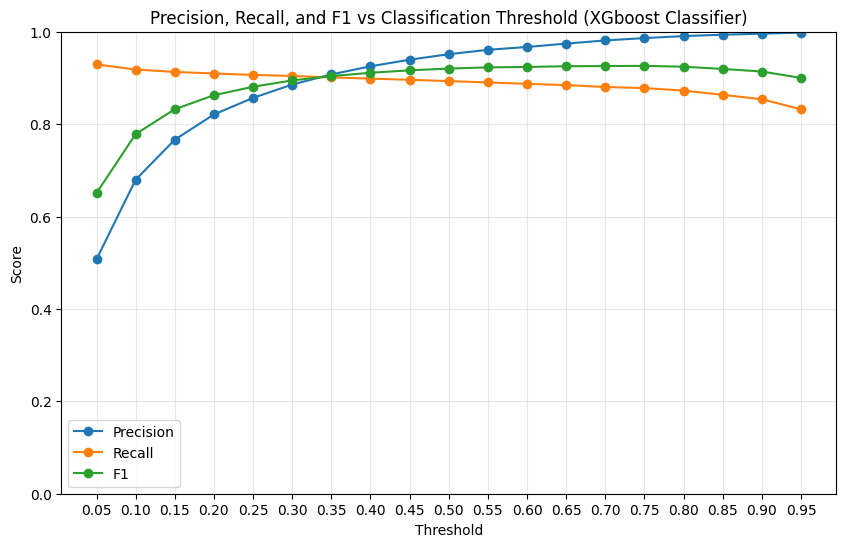

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_summary_xgb["threshold"],
    threshold_summary_xgb["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_summary_xgb["threshold"],
    threshold_summary_xgb["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_summary_xgb["threshold"],
    threshold_summary_xgb["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 vs Classification Threshold (XGboost Classifier)")

plt.xticks(threshold_summary_xgb["threshold"])
plt.ylim(0, 1)

plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig("threshold_evaluation_xgb.png", dpi=300, bbox_inches="tight")

plt.show()

In [23]:
# =========================================================
# FIT FINAL MODEL PADA SELURUH DEVELOPMENT SET
# =========================================================

best_xgb_pipeline.fit(X_dev, y_dev)

print("Final model fitted on entire X_dev.")

Final model fitted on entire X_dev.


## Model Evaluation on test set

In [24]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

# ---------------------------------------------------------
# 1. PREDICT PROBABILITY
# ---------------------------------------------------------

# IMPORTANT:
# best_xgb_pipeline sudah fitted pada seluruh X_dev, y_dev
# dari GridSearchCV karena refit=True

y_test_prob = best_xgb_pipeline.predict_proba(X_test)[:, 1]

# Gunakan threshold yang SUDAH dipilih dari CV
y_test_pred = (
    y_test_prob >= best_threshold
).astype(int)

In [25]:
# ---------------------------------------------------------
# 2. BASIC INFORMATION
# ---------------------------------------------------------

print("===== TEST SET INFORMATION =====")

print(f"Test samples              : {len(y_test):,}")
print(f"Actual laundering         : {y_test.sum():,}")
print(f"Actual non-laundering     : {(y_test == 0).sum():,}")
print(f"Positive prevalence       : {y_test.mean():.4%}")
print(f"Chosen threshold          : {best_threshold:.2f}")
print(f"Predicted laundering      : {y_test_pred.sum():,}")
print(f"Predicted positive rate   : {y_test_pred.mean():.4%}")

===== TEST SET INFORMATION =====
Test samples              : 1,425,728
Actual laundering         : 1,697
Actual non-laundering     : 1,424,031
Positive prevalence       : 0.1190%
Chosen threshold          : 0.75
Predicted laundering      : 1,680
Predicted positive rate   : 0.1178%


In [26]:
# ---------------------------------------------------------
# 3. MAIN PERFORMANCE METRICS
# ---------------------------------------------------------

test_pr_auc = average_precision_score(
    y_test,
    y_test_prob
)

test_roc_auc = roc_auc_score(
    y_test,
    y_test_prob
)

test_precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

print("\n===== TEST SET PERFORMANCE =====")

print(f"PR-AUC    : {test_pr_auc:.4f}")
print(f"ROC-AUC   : {test_roc_auc:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1-score  : {test_f1:.4f}")
print(f"Accuracy  : {test_accuracy:.4f}")



===== TEST SET PERFORMANCE =====
PR-AUC    : 0.9936
ROC-AUC   : 1.0000
Precision : 0.9958
Recall    : 0.9859
F1-score  : 0.9908
Accuracy  : 1.0000


In [27]:
# ---------------------------------------------------------
# 4. CONFUSION MATRIX
# ---------------------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_pred
).ravel()

print("\n===== CONFUSION MATRIX =====")

print(f"True Negative  (TN): {tn:,}")
print(f"False Positive (FP): {fp:,}")
print(f"False Negative (FN): {fn:,}")
print(f"True Positive  (TP): {tp:,}")


===== CONFUSION MATRIX =====
True Negative  (TN): 1,424,024
False Positive (FP): 7
False Negative (FN): 24
True Positive  (TP): 1,673


In [28]:
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"\nSpecificity : {specificity:.4f}")
print(f"FPR        : {fpr:.4f}")
print(f"FNR        : {fnr:.4f}")


Specificity : 1.0000
FPR        : 0.0000
FNR        : 0.0141


In [29]:
# ---------------------------------------------------------
# 5. CLASSIFICATION REPORT
# ---------------------------------------------------------

print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=[
            "Non-Laundering",
            "Laundering"
        ],
        digits=4,
        zero_division=0
    )
)



===== CLASSIFICATION REPORT =====
                precision    recall  f1-score   support

Non-Laundering     1.0000    1.0000    1.0000   1424031
    Laundering     0.9958    0.9859    0.9908      1697

      accuracy                         1.0000   1425728
     macro avg     0.9979    0.9929    0.9954   1425728
  weighted avg     1.0000    1.0000    1.0000   1425728



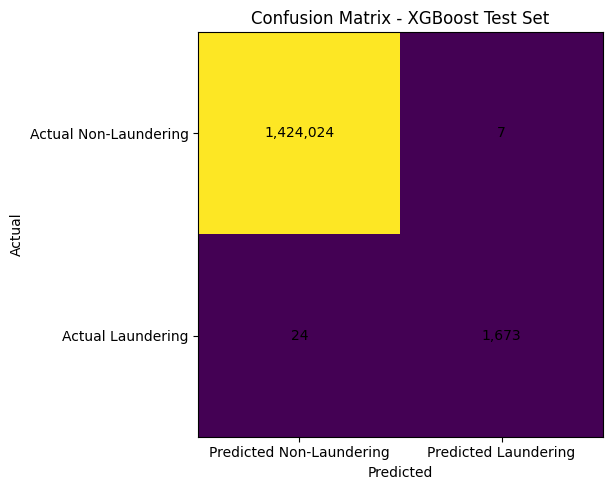

In [30]:
# ---------------------------------------------------------
# 6. CONFUSION MATRIX VISUALIZATION
# ---------------------------------------------------------

cm = np.array([
    [tn, fp],
    [fn, tp]
])

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Predicted Non-Laundering",
    "Predicted Laundering"
])

ax.set_yticklabels([
    "Actual Non-Laundering",
    "Actual Laundering"
])

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix - XGBoost Test Set")

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

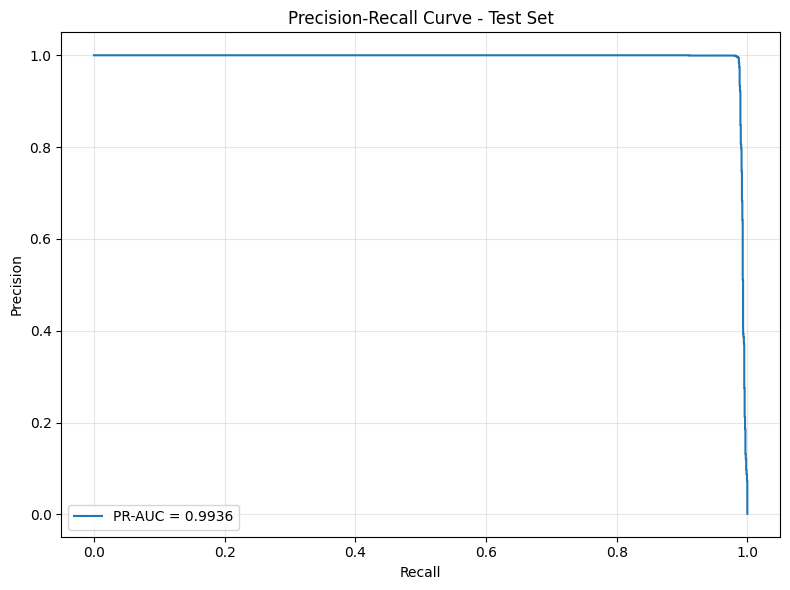

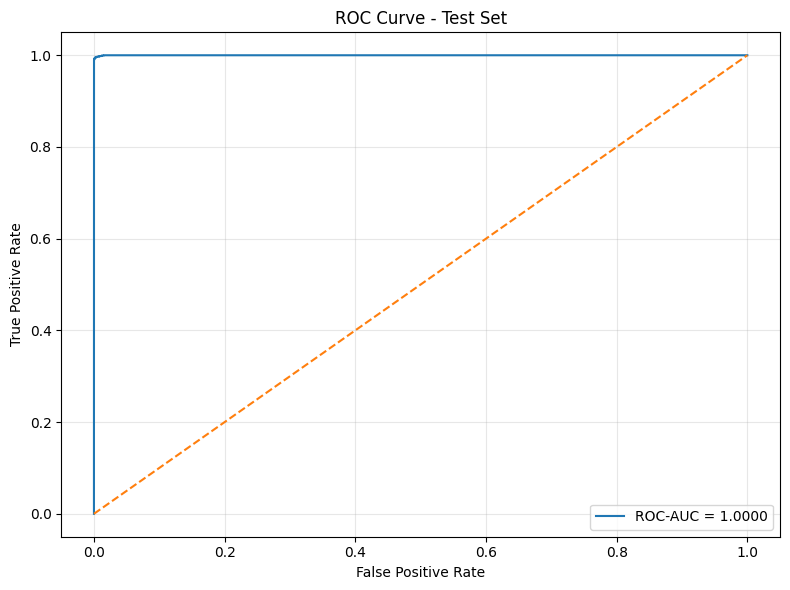

In [31]:
# ---------------------------------------------------------
# 7. PRECISION-RECALL CURVE
# ---------------------------------------------------------

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"PR-AUC = {test_pr_auc:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Test Set")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 8. ROC CURVE
# ---------------------------------------------------------

fpr_curve, tpr_curve, roc_thresholds = roc_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_curve,
    tpr_curve,
    label=f"ROC-AUC = {test_roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## save best model

In [32]:
import joblib
import json
import os

# =========================================================
# FINAL MODEL
# =========================================================
# best_xgb_pipeline berasal dari:
# best_xgb_pipeline = grid_search.best_estimator_
#
# GridSearchCV secara default melakukan refit pada seluruh X_dev,
# jadi pipeline ini sudah menjadi final fitted model.

model_bundle = {
    "pipeline": best_xgb_pipeline,

    # Threshold hasil CV
    "threshold": float(best_threshold),

    # Simpan informasi feature agar inference konsisten
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "feature_cols": feature_cols,

    # Metadata
    "target_col": target_col,
    "model_type": "XGBoost",
    "random_state": 42
}

model_path = "aml_xgb_model.pkl"

joblib.dump(
    model_bundle,
    model_path,
    compress=3
)

print(f"Model berhasil disimpan di:")
print(model_path)

print(f"\nUkuran file: {os.path.getsize(model_path) / (1024**2):.2f} MB")

Model berhasil disimpan di:
aml_xgb_model.pkl

Ukuran file: 0.18 MB
